<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_6_kldiv.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# BYU CS 473 — KL Divergence

In this assignment, you will learn the basics of **Kullback–Leibler (KL) divergence**. KL divergence measures how one probability distribution differs from another.

---

## Learning Goals
- Understand the definition of KL divergence  
- Compute KL divergence between two Gaussian distributions  
- Understand why KL divergence is always non-negative  
- Relate KL divergence to Maximum Likelihood Estimation (MLE)  
- Compare forward vs reverse KL divergence


## 1. Definition

For discrete distributions:

$D_{\text{KL}}(P \,\|\, Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}$

For continuous distributions:

$D_{\text{KL}}(P \,\|\, Q) = \int p(x) \log \frac{p(x)}{q(x)} dx$

- KL divergence is **not symmetric**: $D_{\text{KL}}(P \,\|\, Q) \neq D_{\text{KL}}(Q \,\|\, P)$
- KL divergence is **not a distance metric**, but it measures how well $Q$ approximates $P$.  


### Exercise 1
In your own words, explain what KL divergence measures.  
Give a real-world analogy (e.g., communication, language modeling).


# **RESPONSE**

**Simple Explanation:**  *KL divergence* measures how much excess surprisal (literally how surprised we should expect to be) when using the (often simplified/approximated) theoretic distribution, $Q$, rather than the true (often noisy) distribution, $P$.  In other words, it is a measurement of the the amount of information loss when using distribution $Q$ to approximate distribution $P$.  A higher KL divergence signals a higher divergence between the two distributions.  KL divergence is always nonnegative and is zero if and only if the $P = Q$.

**Real-World Analogy:**  Fraud detection in banking.  Let $Q$ represent the bank's model for a typical probability distribution of a given individual's everyday transactions and $P$ represent today's sequence of transactions.  By comparing the KL divergence of the two distributions, a bank may (and often will) trigger a fraud alert if the KL divergence is sufficiently high (diverging from their ordinary pattern).

## 2. Example: KL Divergence Between Two Gaussians

If $P = \mathcal{N}(\mu_p, \sigma_p^2)$ and $Q = \mathcal{N}(\mu_q, \sigma_q^2)$, the KL divergence is:

$D_{\text{KL}}(P \,\|\, Q) = \log \frac{\sigma_q}{\sigma_p} + \frac{\sigma_p^2 + (\mu_p - \mu_q)^2}{2\sigma_q^2} - \frac{1}{2}$


In [1]:
import numpy as np

def kl_gaussian(mu_p, sigma_p, mu_q, sigma_q):
    return np.log(sigma_q/sigma_p) + (sigma_p**2 + (mu_p - mu_q)**2)/(2*sigma_q**2) - 0.5

# Example
print("KL(P||Q) with mu_p=0, sigma_p=1, mu_q=1, sigma_q=2:")
kl_gaussian(0, 1, 1, 2)

KL(P||Q) with mu_p=0, sigma_p=1, mu_q=1, sigma_q=2:


np.float64(0.4431471805599453)

### Exercise 2
- Compute ${\text{KL}}(P \,\|\, Q)$ for several pairs of Gaussian distributions.  
- Which matters more: differences in mean, or differences in variance?  
- Plot ${\text{KL}}(P \,\|\, Q)$ as $μ_q$ varies from -3 to 3, holding σ fixed.


In [10]:
print('Shift Mean (1) or Variance (2) by Two Units')
print('')

# Baseline: P = N(0, 2^2), so variance = 4

print("(1) Increase mean by 2:")
print("P: mu=0, variance=4; Q: mu=2, variance=4")
print(kl_gaussian(0, 2, 2, 2))
print('')

print("(2) Increase variance by 2:")
print("P: mu=0, variance=4; Q: mu=0, variance=6")
print(kl_gaussian(0, 2, 0, np.sqrt(6)))
print('')


print('Shift Mean (3) or Variance (4) by Three Units')
print('')

print("(3) Increase mean by 3:")
print("P: mu=0, variance=4; Q: mu=3, variance=4")
print(kl_gaussian(0, 2, 3, 2))
print('')

print("(4) Increase variance by 3:")
print("P: mu=0, variance=4; Q: mu=0, variance=7")
print(kl_gaussian(0, 2, 0, np.sqrt(7)))

Shift Mean (1) or Variance (2) by Two Units

(1) Increase mean by 2:
P: mu=0, variance=4; Q: mu=2, variance=4
0.5

(2) Increase variance by 2:
P: mu=0, variance=4; Q: mu=0, variance=6
0.03606588738741545

Shift Mean (3) or Variance (4) by Three Units

(3) Increase mean by 3:
P: mu=0, variance=4; Q: mu=3, variance=4
1.125

(4) Increase variance by 3:
P: mu=0, variance=4; Q: mu=0, variance=7
0.06552217968199714


# **RESPONSE**
---

Above, I ran two experiments where I first computed the KL divergence after shifting just the mean by $x$ units (while keeping variance constant) and then computed the KL divergence after shifting only the variance by $x$ units (while keeping the mean constant).  In the first experiment (see lines (1) and (2)), (2) had a noticeably higher KL divergence, signifying that the change in variance was more consequential than the change in mean.  In my second experiment (see lines (3) and (4)), (3) had a higher KL divergence value, signifying that the change in mean was more consequential than the change in variance.

In a more rigorous analysis, neither the differences in mean nor the differences in variance is more significant as both affect the KL divergence quadratically near the optimum (although variance differences can become especially noticeable due to their presence in the denominator of the closed-form solution of the KL divergence [coded in the provided function]).  Ultimately, neither is more consequential than the other and the main determining factor is based on the scale of variance and mean in the specific distirbutions being measured.

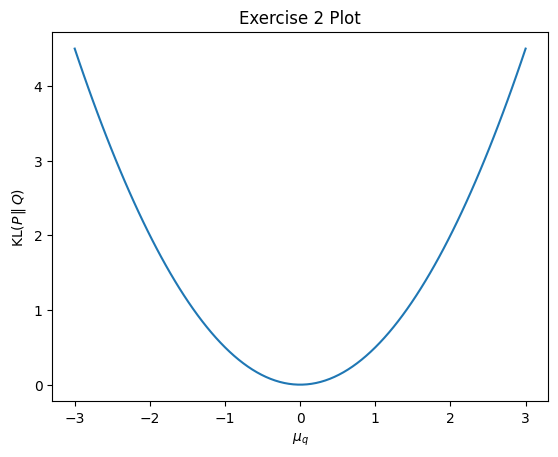

In [3]:
import matplotlib.pyplot as plt

# Plot KL(P, Q) as μ_q varies from -3 to 3, holding σ fixed.
mu_samps = np.linspace(-3, 3, 100, endpoint=True)
sigma = 1
mu_p = 0
kl_vals = [kl_gaussian(mu_p, sigma, mu_q, sigma) for mu_q in mu_samps]
plt.plot(mu_samps, kl_vals)

plt.xlabel(r'$μ_q$')
plt.ylabel(r'${\text{KL}}(P \,\|\, Q)$')
plt.title('Exercise 2 Plot')

plt.show()

## 3. Non-Negativity of KL Divergence

**Gibbs’ Inequality**:  
$D_{\text{KL}}(P \,\|\, Q) \geq 0$

with equality if and only if $P = Q$.  
This means the "distance" is never negative.

Intuition: if you approximate $P$ with $Q$, you can never do better than the true distribution.


In [4]:
# Quick numerical experiment
p = np.array([0.4, 0.6])
q = np.array([0.5, 0.5])
kl = np.sum(p * np.log(p/q))
kl


np.float64(0.020135513550688863)

### Exercise 3
- Construct two different discrete distributions $P$ and $Q$.  
- Compute ${\text{KL}}(P \,\|\, Q)$ and ${\text{KL}}(Q \,\|\, P)$.  
- Verify that both are ≥ 0.  
- When do you get $\text{KL} = 0$?


In [5]:
# Your code here
from scipy.stats import norm, binom, entropy
import numpy as np

x = np.arange(101)

P = binom.pmf(x, n=100, p=0.4)
Q = binom.pmf(x, n=100, p=0.5)

kl_diff_P_Q = entropy(P, Q)
kl_diff_Q_P = entropy(Q, P)
kl_same_P = entropy(P, P)
kl_same_Q = entropy(Q, Q)

print(r'KL(P || Q) = ', kl_diff_P_Q)
print(r'KL(Q || P) = ', kl_diff_Q_P)
print(r'KL(P || P) = ', kl_same_P)
print(r'KL(Q || Q) = ', kl_same_Q)

KL(P || Q) =  2.013551355068887
KL(Q || P) =  2.041099726012754
KL(P || P) =  0.0
KL(Q || Q) =  0.0


As evidenced above, all KL divergences are $\geq 0$.  Moreover, as mentioned in my discussion in `Exercise 1`, $\text{KL}(P\|Q) = 0 \iff P = Q$, as shown in the two additional lines output at the end of the coding cell immediately above.

## 4. KL Divergence and Maximum Likelihood Estimation

Suppose data is generated from distribution P, and we fit model Qθ.  

- MLE maximizes likelihood:   
  $\theta^* = \arg \max_\theta \sum \log q_\theta(x_i)$
- Equivalent to minimizing:  
  $D_{\text{KL}}(P \,\|\, Q_\theta)$

Thus, **MLE is KL minimization**: we make our model Qθ as close as possible to the true distribution P.


### Exercise 4
Explain in your own words:
- Why minimizing ${\text{KL}}(P \,\|\, Q)$ is the same as maximizing likelihood.  
- Why this interpretation helps us understand model training.


# **Response**

1. Minimizing $\text{KL}(P\|Q)$ is the same as maximizing likelihood because the only part of the KL-divergence computation that depends on the model parameters is exactly the negative expected log-likelihood.  Therefore, minimizing $\text{KL}(P\|Q)$ is equivalent to maximizing the (log-)likelihood.

2. This interpretation helps us understand model training because negative log-likelihood is an important training objective in and of itself since it nudges our model distribution ($Q$) toward the (unknown) data-generating distribution $P$.

## 5. Forward vs Reverse KL

- **Forward KL:** $D_{\text{KL}}(P \,\|\, Q)$  
  - Penalizes missing modes ($Q$ must cover all support of $P$).  
  - "Mode covering."

- **Reverse KL:** $D_{\text{KL}}(Q \,\|\, P)$  
  - Penalizes putting mass where $P$ has none.  
  - "Mode seeking."

This asymmetry explains why different algorithms (e.g. variational inference vs expectation propagation) behave differently.


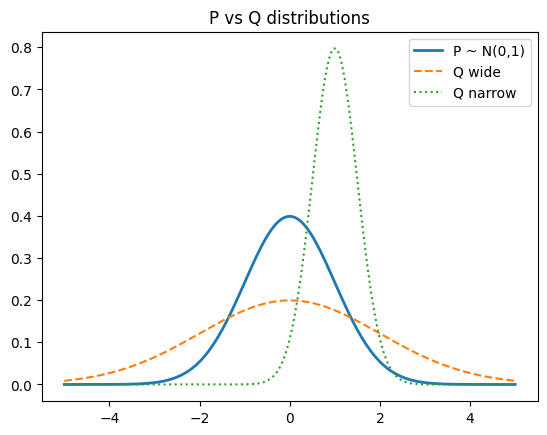

In [6]:
import matplotlib.pyplot as plt
import scipy.stats as stats

x = np.linspace(-5, 5, 200)
p = stats.norm(0, 1).pdf(x)   # true distribution
q1 = stats.norm(0, 2).pdf(x)  # wide Q
q2 = stats.norm(1, 0.5).pdf(x) # narrow Q

plt.plot(x, p, label="P ~ N(0,1)", linewidth=2)
plt.plot(x, q1, label="Q wide", linestyle="--")
plt.plot(x, q2, label="Q narrow", linestyle=":")
plt.legend()
plt.title("P vs Q distributions")
plt.show()


### Exercise 5
1. Compute both ${\text{KL}}(P \,\|\, Q)$ and ${\text{KL}}(Q \,\|\, P)$ for $P=N(0,1)$, $Q=N(1,0.5)$.  
2. Which is larger? Why?  
3. In which case would forward KL be more appropriate? Reverse KL?


In [7]:
# Your code here
mu_p, sigma_p = 0, 1
mu_q, sigma_q = 1, 0.5

KL_P_Q = kl_gaussian(mu_p=mu_p, sigma_p=sigma_p, mu_q=mu_q, sigma_q=sigma_q)
KL_Q_P = kl_gaussian(mu_p=mu_q, sigma_p=sigma_q, mu_q=mu_p, sigma_q=sigma_p)

print(r'KL(P || Q) = ', KL_P_Q)
print(r'KL(Q || P) = ', KL_Q_P)
print('')

if KL_P_Q > KL_Q_P:
    print(r'KL(P || Q) > KL(Q || P).')

elif KL_Q_P > KL_P_Q:
    print(r'KL(Q || P) > KL(P || Q).')

else:
    print(r'KL(P || Q) = KL(Q || P).')

KL(P || Q) =  2.8068528194400546
KL(Q || P) =  0.8181471805599454

KL(P || Q) > KL(Q || P).


# **RESPONSES**

1. See the coding cell above (and the accompanying outputs) for my response.

2. As shown in the code immediately above, ${\text{KL}}(P \,\|\, Q)$ is larger than ${\text{KL}}(Q \,\|\, P)$.  This is true because the distribution $P$ is significantly wider (it has quadruple the comparative variance) than the distribution $Q$.  Because forward KL divergence punishes relatively missing modes (in the approximated distribution/second slot), the KL divergence is much higher when the second distribution (i.e., the distribution $B$ in $\text{KL}(A \| B)$) does not assign appreciable probabilities to "cover" the dense regions of the first distribution.  Because $Q$ fails to cover $P$ much more than $P$ fails to cover $Q$, we find that ${\text{KL}}(P \,\|\, Q) > {\text{KL}}(Q \,\|\, P)$.

3. It therefore (see my response to Part 2 of this exercise) is more appropriate to use forward KL divergence when not representing meaningful probability mass in $P$ is particularly costly (i.e., $P$ is not adequately "covered").  Similarly, it is more appropriate to use reverse KL divergence when not representing meaningful probability mass in $Q$ is particularly costly.

## 6. Reflection

### Exercise 6
Answer in 2–3 sentences each:

1. Why is KL divergence always non-negative?  
2. How does KL divergence connect to MLE?  
3. Why do forward and reverse KL behave differently?  


# **Your response here**

1. As a mathematician, I think the only proper answer to the first question is a proof, as follows (enjoy!).

*Proof:*  Let $t = \frac{q(x)}{p(x)}$ and recall that $\log (t) \leq t - 1 \iff -\log (\frac{q(x)}{p(x)}) \geq 1 - \frac{q(x)}{p(x)} \iff -p(x) \log (\frac{q(x)}{p(x)}) \geq p(x) - q(x).$

Now, observe that, by definition, $\text{D}_{KL} (P\|Q) = \Sigma_x p(x) \log (\frac{p(x)}{q(x)}) = \Sigma_x -p(x) \log (\frac{q(x)}{p(x)}) \geq \Sigma_x (p(x) - q(x)) = \Sigma_x p(x) - \Sigma_x q(x) = 0$ (since both terms in the right-hand side of the final equality are probability distributions, so they sum to one).

Hence, KL divergence is always non-negative.  *QED*

2. KL divergence connects to the MLE because it is mathematically equivalent (I'll spare the proof this time).  The general intuition behind this is because $D_{KL}(P\|Q) = \mathbb{E}[\log P(x)] - \mathbb{E} [\log Q(x|\theta)]$, which is essentially the difference of the negative entropy value (which is constant and does not depend on the parameters, $\theta$) and the expected log likelihood.  Thus, minimizing KL divergence is equivalent to maximizing the the expected log-likelihood.

3. Forward and reverse KL behave differently because KL divergence is not a symmetric operation.  To see why, observe that $D_{KL}(P\|Q) = \Sigma_x P(x) \log(\frac{P(x)}{Q(x)})$, so KL divergence is weighted only by the first distribution (in this case, $P$).  Moreover, $\log (\frac{P(x)}{Q(x)}) \neq \log (\frac{Q(x)}{P(x)})$ generally.  Thus, $D_{KL}(P\|Q) \neq D_{KL} (Q\|P)$ generally either.